# 📊 Jalon 3 : Évaluation du modèle hybride

Ce notebook charge les artefacts produits par `05_modelisation.qmd` (modèle XGBoost + prédictions sur le jeu de test) et restitue les indicateurs de performance ainsi que les visualisations métier (matrice de confusion, importance des facteurs d'achat).

### 1. Chargement des artefacts

In [1]:
import os
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

racine_projet = os.path.abspath('../')
processed_dir = os.path.join(racine_projet, "data", "processed")
assets_dir = os.path.join(racine_projet, "report", "assets")

xgb_model = joblib.load(os.path.join(processed_dir, "xgb_model.pkl"))
eval_data = joblib.load(os.path.join(processed_dir, "eval_data.pkl"))
y_test, y_pred = eval_data['y_test'], eval_data['y_pred']

### 2. Rapport de classification

In [2]:
print("--- RAPPORT DE PERFORMANCE (Test Set) ---")
print(classification_report(y_test, y_pred, target_names=['Non-Acheteur (0)', 'Acheteur (1)']))

--- RAPPORT DE PERFORMANCE (Test Set) ---
                  precision    recall  f1-score   support

Non-Acheteur (0)       0.91      0.94      0.92       381
    Acheteur (1)       0.58      0.49      0.53        67

        accuracy                           0.87       448
       macro avg       0.75      0.71      0.73       448
    weighted avg       0.86      0.87      0.87       448



### 3. Matrice de confusion

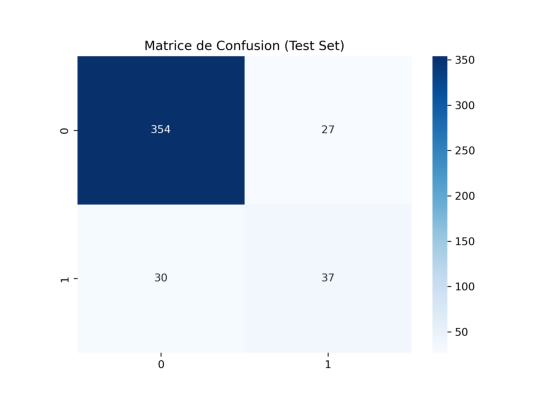

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.imshow(plt.imread(os.path.join(assets_dir, 'matrice.png')))
ax.axis('off')
plt.show()

### 4. Top 10 des facteurs d'achat

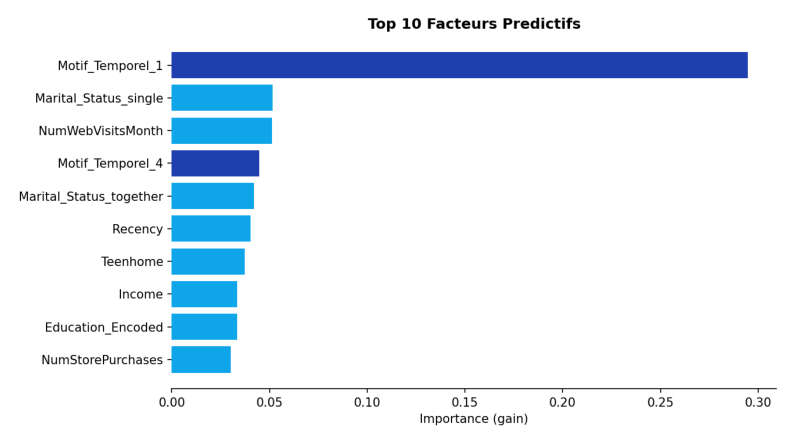

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(plt.imread(os.path.join(assets_dir, 'importance.png')))
ax.axis('off')
plt.show()